# Exercise 4 — Dimensionality Reduction

## Part A — Why Do We Need Dimensionality Reduction?

Real datasets often contain many features.

Example:
```
apartment:
- size
- number of rooms
- floor
- location score
- age
- distance to center
- noise level
- energy consumption
...
```

As the number of features increases:

* visualization becomes difficult
* models become slower
* features may become redundant
* noise increases
* overfitting becomes easier

This is related to: `the curse of dimensionality`

### Goal of Dimensionality Reduction

Reduce the number of features while preserving the important structure of the data.

### Main Idea

Instead of describing the data with many correlated features: `(size, rooms, floor, age, ...)` we create: `new compact features` called `principal components`.

If two features contain similar information: `size ↔ number of rooms` then we may not need both.

PCA tries to find:

* the main directions of variation
* the most informative axes

## Part B — Generate Correlated Data

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Apartment example
n = 120

size = np.random.normal(70, 15, n)

rooms = size / 25 + np.random.normal(0, 0.35, n)

X = np.column_stack([size, rooms])

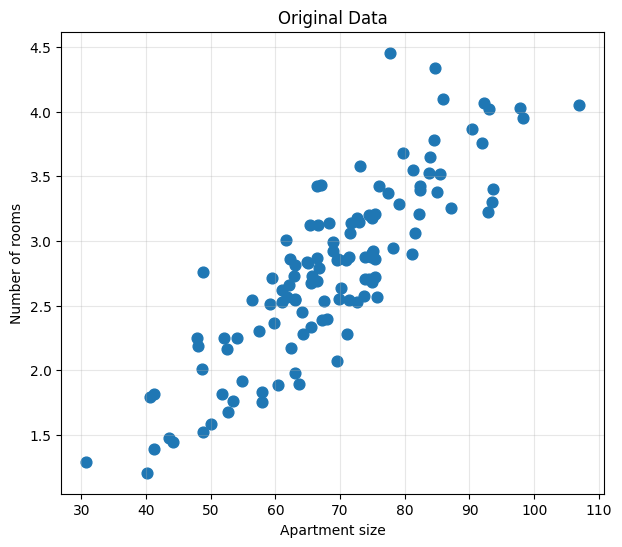

In [2]:
plt.figure(figsize=(7,6))

plt.scatter(X[:,0], X[:,1], s=60)

plt.xlabel("Apartment size")
plt.ylabel("Number of rooms")

plt.title("Original Data")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Are the features correlated?
- Yes. size increase --> number of rooms also increase --> it shows an upward trend

2. Does the cloud follow a direction?
- Yes. Upward and to the right.
  
3. Could one feature approximately predict the other?
- I think yes becuase the relationtionship is nearly linear (we can draw a line to show the correlation & also knowing the size might give an estimate number of rooms)

## Part C — Apply PCA

Standardize the data. Why do we need to do this?

Data standardization is the process of scaling variables so they have a mean of 0 and a standard deviation 1. It is a mandatory first step in PCA to prevent features with larger units or magnitudes from disproportionately dominating the analysis.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Run PCA

In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Explained Variance

In [5]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.92920937 0.07079063]


`PC1 = direction with maximum variance`

PCA tries to find the direction where the data spreads the most.

### Visualize PCA Directions

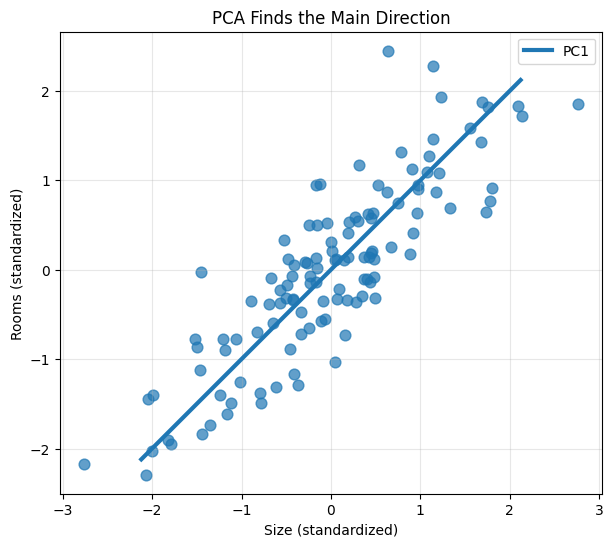

In [6]:
mean = X_scaled.mean(axis=0)

pc1 = pca.components_[0]

t = np.linspace(-3, 3, 100)

pc1_line = mean + t[:, None] * pc1

plt.figure(figsize=(7,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60,
    alpha=0.7
)

plt.plot(
    pc1_line[:,0],
    pc1_line[:,1],
    linewidth=3,
    label="PC1"
)

plt.xlabel("Size (standardized)")
plt.ylabel("Rooms (standardized)")

plt.title("PCA Finds the Main Direction")

plt.legend()

plt.grid(True, alpha=0.3)

plt.axis("equal")

plt.show()

### Questions

1. Why does PCA choose this direction?
- Because that's where data varies the most. It captures the maximum spread (variance) of the data points

2. What does “maximum variance” mean visually?
-  Maximum variances: the possibile line draw through the cluster of data points with direction where data points are spreading out the most along that direction.

3. Why is this direction informative?
- Because it captures the underlying relationship of both original features (sizes and room) into a single, highly representative feature.

## Part D — Reduce to One Dimension

In [7]:
pca_1d = PCA(n_components=1)

X_reduced = pca_1d.fit_transform(X_scaled)

print(X_reduced.shape)

(120, 1)


### Before vs After PCA

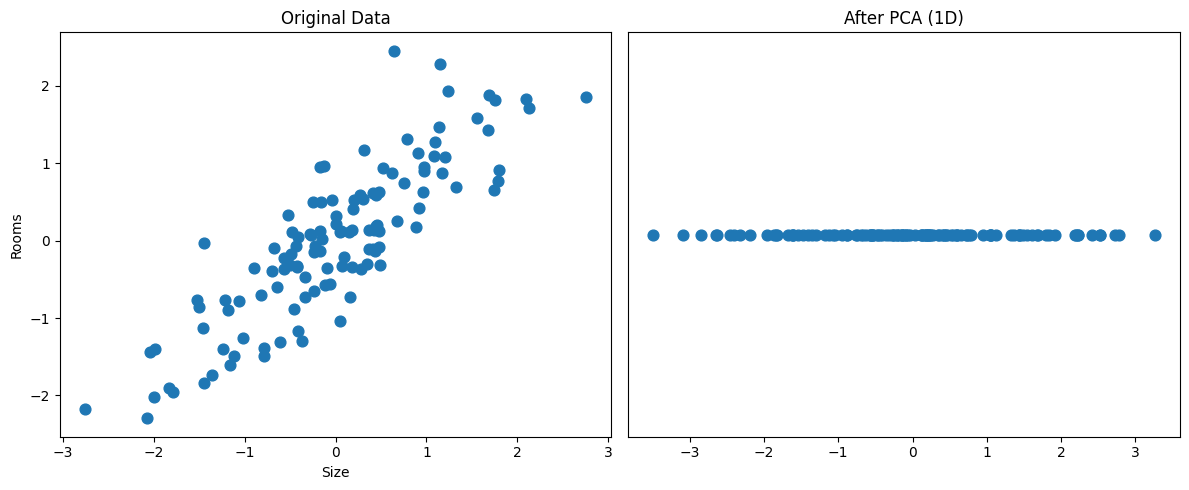

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original
axes[0].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60
)

axes[0].set_title("Original Data")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Rooms")

# Reduced
axes[1].scatter(
    X_reduced[:,0],
    np.zeros_like(X_reduced[:,0]),
    s=60
)

axes[1].set_title("After PCA (1D)")
axes[1].set_yticks([])

plt.tight_layout()

plt.show()

Even after reducing dimensions: `similar apartments stay close together`

PCA compresses the data while preserving important relationships.

## Part E — Real Dataset

Now apply PCA to a real dataset.

Choose one dataset from the table below.

| Dataset | Link | Features | What PCA can help with |
|---|---|---|---|
| Iris | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) | flower measurements | visualize species in 2D |
| Wine | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) | chemical properties | reduce many chemical features |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | tumor measurements | visualize benign vs malignant cases |
| Digits | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) | image pixels | compress image features |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | biological measurements | visualize species groups |
| Wine Quality | [Open dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) | chemical properties | reduce correlated wine features |

In [17]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

### Apply PCA to 2D

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Visualize Reduced Data

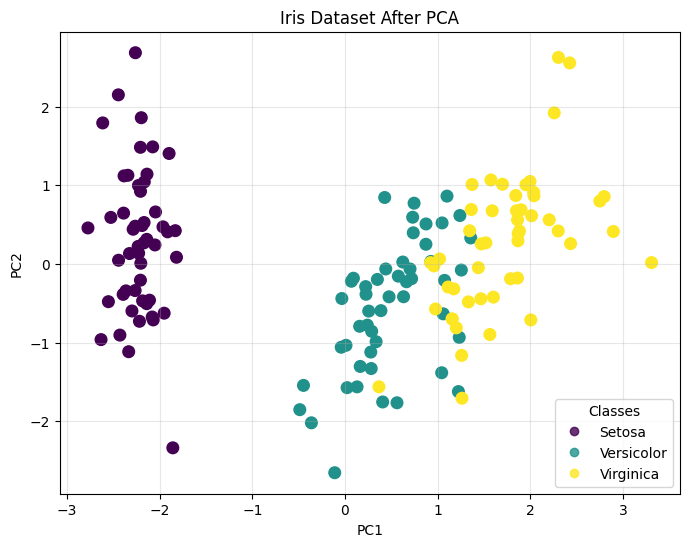

In [20]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    s=70
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Iris Dataset After PCA")

plt.grid(True, alpha=0.3)

#add name
target_names = ['Setosa', 'Versicolor', 'Virginica'] 
plt.legend(handles, target_names, title="Classes")


plt.show()

### Questions

1. Do the classes separate well?
- Partially. the purple (setosa) seperate from the two other. The other two are not perfectly seprated, but have a clear boundary
  
2. Which species overlap?
- The vesicolor (green) and virginica (yellow) overlap in the middle. (i guess the reason is their petal and sepal infos are similar so they blending in the graph)

3. Why is PCA useful for visualization?
- It makes the impossible --> to seeable. And the dataset, there are 4 dimensions (sepal length, sepal width, petal length, petal width) --> 4D graph. But it compress into 2D (PC1, PC2) as keeping many original variance. --> spot clusters, trends and outliers

4. Why can PCA help machine learning models?
- Removes redundancy: Correlated features carry overlapping information, PCA merges into independent components
- Reduces noise. (put away random noise and redundant data, leaving important patterns)
- Speeds the training (Less math to do --> faster and less expensive)
- Prevent overfitting (help the model not to memorize the training data)

## Part F — Train a Model with Logistic Regression and PCA


Look in the previous exercises and find how to load a dataset, separate it in train/dev/test or just train/dev datasets. 

1. Use [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) or [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) depending on the task to train and test a model. Please report accuracy, precision and recall.
2. Use then PCA to reduce the dimensionality of the data, and redo step 1. Report metrics and see the difference. Is there any?

In [43]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA

In [44]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#1 without PCA
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print("1. Logistic Regression")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.3f}\n")

#2. with PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

log_reg_pca = LogisticRegression(max_iter=1000)
log_reg_pca.fit(X_train_pca, y_train)
y_pred_pca = log_reg_pca.predict(X_test_pca)

print("2. Logistic Regression + PCA")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_pca):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_pca, average='macro'):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_pca, average='macro'):.3f}")

1. Logistic Regression
Accuracy:  1.000
Precision: 1.000
Recall:    1.000

2. Logistic Regression + PCA
Accuracy:  0.900
Precision: 0.903
Recall:    0.896


Yes, there are different as the performance drop. I think for some reasons:  
- Information lose. It compress from 4 features into 2 dimensions. And it might drop the components to seperate the overlapping parts (for versicolor and virginica)
- Scale sensitivity. without standardscaler, features with learger numeric values (sepal length) will dominates the principal components, making predictive feature (like petal width) will be left out.
- Hard to classify accurately the complex boundaries.
- I think it would help if there are many features, but not in this case.